In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import sys
import os

project_root = Path.cwd().resolve()
# Notebook lives at models/wnba/ — climb to repo root if needed
if not (project_root / "data").exists():
    project_root = project_root.parent.parent

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)
os.chdir(project_root_str)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


In [4]:
from src.pipeline.features.context_features import ContextFeatureEngineer

seasons = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
frames = []
for yr in seasons:
    path = f"data/processed/wnba_{yr}_Regular_Season_training_data.parquet"
    season_df = pd.read_parquet(path)
    season_df = ContextFeatureEngineer(league="wnba").enrich(season_df)
    frames.append(season_df)

df = pd.concat(frames, ignore_index=True)
df.sample(10)



Context features (pos, rest, trends, ranks, std/var, games played)

Merging player positions...
  loaded 157 positions from wnba_2018_players.csv (season=2018)
  pos filled on 4,359 / 4,418 rows (1 season file(s))

Adding games_played to date...
  games_played + season_games_played

Adding rest / back-to-back...
  days_rest + is_back_to_back (229 B2B rows)

Adding fatigue window features...
  games_played_last_7/14_days + min_sum_last_7_days (from minutes)

Adding 5v20 trends...
  added 7 trend cols: ['base_min_trend_5v20', 'base_pts_per_min_trend_5v20', 'adv_ts_pct_trend_5v20', 'adv_usg_pct_trend_5v20', 'base_ast_per_min_trend_5v20', 'base_oreb_per_min_trend_5v20', 'base_dreb_per_min_trend_5v20']

Adding within-team ranks...
  added 7 rank cols: ['team_pts_per_min_rank_l10', 'team_ast_per_min_rank_l10', 'team_oreb_per_min_rank_l10', 'team_dreb_per_min_rank_l10', 'team_ts_pct_rank_l10', 'team_usg_pct_rank_l10', 'team_min_rank_l10']

Adding rolling team rank for pts_per_min (L10)...
  

,game_id,player_id,team_id,player_name,game_date,season_year,matchup,minutes,pts_per_min,fga_per_min,fg3a_per_min,fta_per_min,oreb_per_min,dreb_per_min,reb_per_min,ast_per_min,tov_per_min,stl_per_min,blk_per_min,blka_per_min,games_played,base_min_ewm_hl5,base_min_roll5,base_min_ewm_hl10,base_min_roll10,base_min_ewm_hl20,base_min_roll20,base_min_lag1,base_min_season_avg,base_fg_pct_ewm_hl5,base_fg_pct_roll5,base_fg_pct_ewm_hl10,base_fg_pct_roll10,base_fg_pct_ewm_hl20,base_fg_pct_roll20,base_fg_pct_lag1,base_fg_pct_season_avg,base_fg3_pct_ewm_hl5,base_fg3_pct_roll5,base_fg3_pct_ewm_hl10,base_fg3_pct_roll10,base_fg3_pct_ewm_hl20,base_fg3_pct_roll20,base_fg3_pct_lag1,base_fg3_pct_season_avg,base_ft_pct_ewm_hl5,base_ft_pct_roll5,base_ft_pct_ewm_hl10,base_ft_pct_roll10,base_ft_pct_ewm_hl20,base_ft_pct_roll20,base_ft_pct_lag1,base_ft_pct_season_avg,base_plus_minus_ewm_hl5,base_plus_minus_roll5,base_plus_minus_ewm_hl10,base_plus_minus_roll10,base_plus_minus_ewm_hl20,base_plus_minus_roll20,base_plus_minus_lag1,base_plus_minus_season_avg,base_pts_per_min_ewm_hl5,base_pts_per_min_roll5,base_pts_per_min_ewm_hl10,base_pts_per_min_roll10,base_pts_per_min_ewm_hl20,base_pts_per_min_roll20,base_pts_per_min_lag1,base_pts_per_min_season_avg,base_fga_per_min_ewm_hl5,base_fga_per_min_roll5,base_fga_per_min_ewm_hl10,base_fga_per_min_roll10,base_fga_per_min_ewm_hl20,base_fga_per_min_roll20,base_fga_per_min_lag1,base_fga_per_min_season_avg,base_fg3a_per_min_ewm_hl5,base_fg3a_per_min_roll5,base_fg3a_per_min_ewm_hl10,base_fg3a_per_min_roll10,base_fg3a_per_min_ewm_hl20,base_fg3a_per_min_roll20,base_fg3a_per_min_lag1,base_fg3a_per_min_season_avg,base_fta_per_min_ewm_hl5,base_fta_per_min_roll5,base_fta_per_min_ewm_hl10,base_fta_per_min_roll10,base_fta_per_min_ewm_hl20,base_fta_per_min_roll20,base_fta_per_min_lag1,base_fta_per_min_season_avg,base_oreb_per_min_ewm_hl5,base_oreb_per_min_roll5,base_oreb_per_min_ewm_hl10,base_oreb_per_min_roll10,base_oreb_per_min_ewm_hl20,base_oreb_per_min_roll20,base_oreb_per_min_lag1,base_oreb_per_min_season_avg,base_dreb_per_min_ewm_hl5,base_dreb_per_min_roll5,base_dreb_per_min_ewm_hl10,base_dreb_per_min_roll10,base_dreb_per_min_ewm_hl20,base_dreb_per_min_roll20,base_dreb_per_min_lag1,base_dreb_per_min_season_avg,base_reb_per_min_ewm_hl5,base_reb_per_min_roll5,base_reb_per_min_ewm_hl10,base_reb_per_min_roll10,base_reb_per_min_ewm_hl20,base_reb_per_min_roll20,base_reb_per_min_lag1,base_reb_per_min_season_avg,base_ast_per_min_ewm_hl5,base_ast_per_min_roll5,base_ast_per_min_ewm_hl10,base_ast_per_min_roll10,base_ast_per_min_ewm_hl20,base_ast_per_min_roll20,base_ast_per_min_lag1,base_ast_per_min_season_avg,base_tov_per_min_ewm_hl5,base_tov_per_min_roll5,base_tov_per_min_ewm_hl10,base_tov_per_min_roll10,base_tov_per_min_ewm_hl20,base_tov_per_min_roll20,base_tov_per_min_lag1,base_tov_per_min_season_avg,base_stl_per_min_ewm_hl5,base_stl_per_min_roll5,base_stl_per_min_ewm_hl10,base_stl_per_min_roll10,base_stl_per_min_ewm_hl20,base_stl_per_min_roll20,base_stl_per_min_lag1,base_stl_per_min_season_avg,base_blk_per_min_ewm_hl5,base_blk_per_min_roll5,base_blk_per_min_ewm_hl10,base_blk_per_min_roll10,base_blk_per_min_ewm_hl20,base_blk_per_min_roll20,base_blk_per_min_lag1,base_blk_per_min_season_avg,base_blka_per_min_ewm_hl5,base_blka_per_min_roll5,base_blka_per_min_ewm_hl10,base_blka_per_min_roll10,base_blka_per_min_ewm_hl20,base_blka_per_min_roll20,base_blka_per_min_lag1,base_blka_per_min_season_avg,adv_off_rating_ewm_hl5,adv_off_rating_roll5,adv_off_rating_ewm_hl10,adv_off_rating_roll10,adv_off_rating_ewm_hl20,adv_off_rating_roll20,adv_off_rating_lag1,adv_off_rating_season_avg,adv_def_rating_ewm_hl5,adv_def_rating_roll5,adv_def_rating_ewm_hl10,adv_def_rating_roll10,adv_def_rating_ewm_hl20,adv_def_rating_roll20,adv_def_rating_lag1,adv_def_rating_season_avg,adv_net_rating_ewm_hl5,adv_net_rating_roll5,adv_net_rating_ewm_hl10,adv_net_rating_roll10,adv_net_rating_ewm_hl20,adv_net_rating_roll20,adv_net_rating_lag1,adv_net_rating_season_avg,ad

In [5]:
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df[['minutes', 'pts_per_min', 'ast_per_min', 'reb_per_min']].describe()


Total number of duplicates: 0
Rows: 39582
Columns: 722


,minutes,pts_per_min,ast_per_min,reb_per_min
count,39582.000000,39580.000000,39580.000000,39580.000000
mean,21.023363,0.365265,0.089548,0.168043
std,10.416752,0.270993,0.093807,0.142947
min,0.000000,0.000000,0.000000,0.000000
25%,12.800000,0.176991,0.000000,0.067467
50%,21.833333,0.350599,0.071986,0.144052
75%,29.833333,0.526010,0.135048,0.240630
max,52.550000,12.500000,2.469136,2.702703


In [6]:
# ── Prop-specific config (WNBA MIN) ───────────────────────────────────────────
MIN_FEATURES = [
    "starting",
    "starter_roll10_pct",
    "team_min_rank_l10",
    "team_usg_pct_rank_l10",
    "base_min_season_avg", # new
    "track_minutes_ewm_hl10",
    "base_min_trend_5v20",
    "base_min_lag1",
]

HOLDOUT_SEASON = "2026"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
TARGET_COL = "minutes"
ROLE_COL = "starting"

# Frozen naive baselines for the MIN hypothesis test (leakage-safe).
NAIVE_PRIMARY = "base_min_season_avg"
NAIVE_SECONDARY = "base_min_lag1"
NAIVE_COLS = [NAIVE_PRIMARY, NAIVE_SECONDARY]
ALPHA = 0.05

QUANTILES = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1695,
    max_depth=3,
    learning_rate=0.052852647946832816,
    subsample=0.5916232263322159,
    colsample_bytree=0.6284413523882679,
    reg_alpha=0.022871045941195746,
    reg_lambda=2.0960269065270034,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
)

MIN_TIERS = {
    "<12.8 min": lambda a: a < 12.8,
    "12.8-21.8 min": lambda a: (a >= 12.8) & (a < 21.8),
    "21.8-30 min": lambda a: (a >= 21.8) & (a < 31.5),
    "30+ min": lambda a: a >= 31.5,
}

ARTIFACT_STEM = "min_wnba_model"

# ── Shared train/eval helpers ─────────────────────────────────────────────────
from models.shared.splits import prepare_splits
from models.shared.train import run_timeseries_cv, run_walk_forward, evaluate_holdout
from models.shared.baselines import (
    run_naive_comparison,
    evaluate_holdout_vs_naive,
    run_quantile_linear_baseline,
)
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import pinball_50

print(f"Number of features: {len(MIN_FEATURES)}")
MIN_FEATURES


Number of features: 8


['starting',
 'starter_roll10_pct',
 'team_min_rank_l10',
 'team_usg_pct_rank_l10',
 'base_min_season_avg',
 'track_minutes_ewm_hl10',
 'base_min_trend_5v20',
 'base_min_lag1']

In [22]:
df = df[(df['minutes'] > 12)]
print(f"After filtering minutes: {df[MIN_FEATURES].shape[0]} rows")


After filtering minutes: 30427 rows


In [23]:
splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    naive_primary=NAIVE_PRIMARY,
    naive_secondary=NAIVE_SECONDARY,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=["minutes"],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]


Train pool (excl. 2026) : 27,375 rows
Holdout   (2026)        : 3,052 rows
Date range (train)   : 2018-05-18 → 2025-10-10
Date range (holdout) : 2026-05-08 → 2026-07-22


In [24]:
# import importlib
# import models.shared.train as train

# importlib.reload(train)
# tune_xgb_quantile = train.tune_xgb_quantile

# result = tune_xgb_quantile(X, y, n_trials=100, n_splits=5)
# XGB_PARAMS = result["best_params"]

In [25]:
tscv_results = run_timeseries_cv(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]


── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n= 4562 | MAE: 4.018 | R²: 0.509 | 80% Coverage: 78.4%
  Starters   | n= 2994 | MAE: 4.311 | Coverage: 77.4%
  Bench      | n= 1568 | MAE: 3.458 | Coverage: 80.4%
  <12.8 min  | n=  111 | MAE: 5.268 | Coverage: 11.7%
  12.8-21.8 min | n= 1552 | MAE: 4.140 | Coverage: 80.0%
  21.8-30 min | n= 1846 | MAE: 3.525 | Coverage: 89.3%
  30+ min    | n= 1053 | MAE: 4.570 | Coverage: 64.0%

TSCV fold 2
  Overall  | n= 4562 | MAE: 4.097 | R²: 0.506 | 80% Coverage: 78.6%
  Starters   | n= 3023 | MAE: 4.409 | Coverage: 78.4%
  Bench      | n= 1539 | MAE: 3.483 | Coverage: 78.9%
  <12.8 min  | n=  100 | MAE: 5.740 | Coverage: 2.0%
  12.8-21.8 min | n= 1473 | MAE: 4.188 | Coverage: 79.4%
  21.8-30 min | n= 1816 | MAE: 3.789 | Coverage: 88.7%
  30+ min    | n= 1173 | MAE: 4.318 | Coverage: 68.4%

TSCV fold 3
  Overall  | n= 4562 | MAE: 3.844 | R²: 0.568 | 80% Coverage: 80.7%
  Starters   | n= 3099 | MAE: 4.

### Naive baseline — MIN hypothesis test

**H0:** The minutes model does not predict significantly better than a naive baseline.  
**H1:** The minutes model predicts significantly better than naive.

**Frozen primary naive:** `base_min_season_avg` (season-to-date expanding mean, shift-then-expand — no same-game leakage).  
**Secondary (reported only):** `base_min_lag1` (last-game minutes).

**Decision rule:** on the same player-games, reject H0 if model MAE < naive MAE **and** one-sided Wilcoxon signed-rank on `|y − ŷ|` has p < 0.05 (model errors stochastically smaller).


In [26]:
naive = run_naive_comparison(
    wf_results,
    ppm_df,
    target_col=TARGET_COL,
    naive_primary=NAIVE_PRIMARY,
    naive_secondary=NAIVE_SECONDARY,
    y_val_last=y_val_last,
    preds_last=preds_last,
    last_fold=last_fold,
    alpha=ALPHA,
)


── Naive baselines on walk-forward validation folds ─────────────────
  Primary H0 predictor : base_min_season_avg
  Secondary (report)   : base_min_lag1
  Alpha                : 0.05

Primary naive (base_min_season_avg) vs model MAE by fold:
  Fold                                             Model    Naive     ΔMAE       n
  WF fold 1  (2022-06-30 → 2023-06-17)             3.830    4.850   -1.019    2514
  WF fold 2  (2023-06-17 → 2023-10-01)             3.924    4.940   -1.016    2812
  WF fold 3  (2023-10-01 → 2024-08-26)             3.767    4.803   -1.036    2487
  WF fold 4  (2024-08-26 → 2025-07-06)             4.039    5.116   -1.077    2826

Secondary naive (base_min_lag1) vs model MAE by fold:
  Fold                                             Model    Naive     ΔMAE       n
  WF fold 1  (2022-06-30 → 2023-06-17)             3.830    5.404   -1.573    2514
  WF fold 2  (2023-06-17 → 2023-10-01)             3.924    5.679   -1.755    2812
  WF fold 3  (2023-10-01 → 2024-08-26)

### Residual Visuals


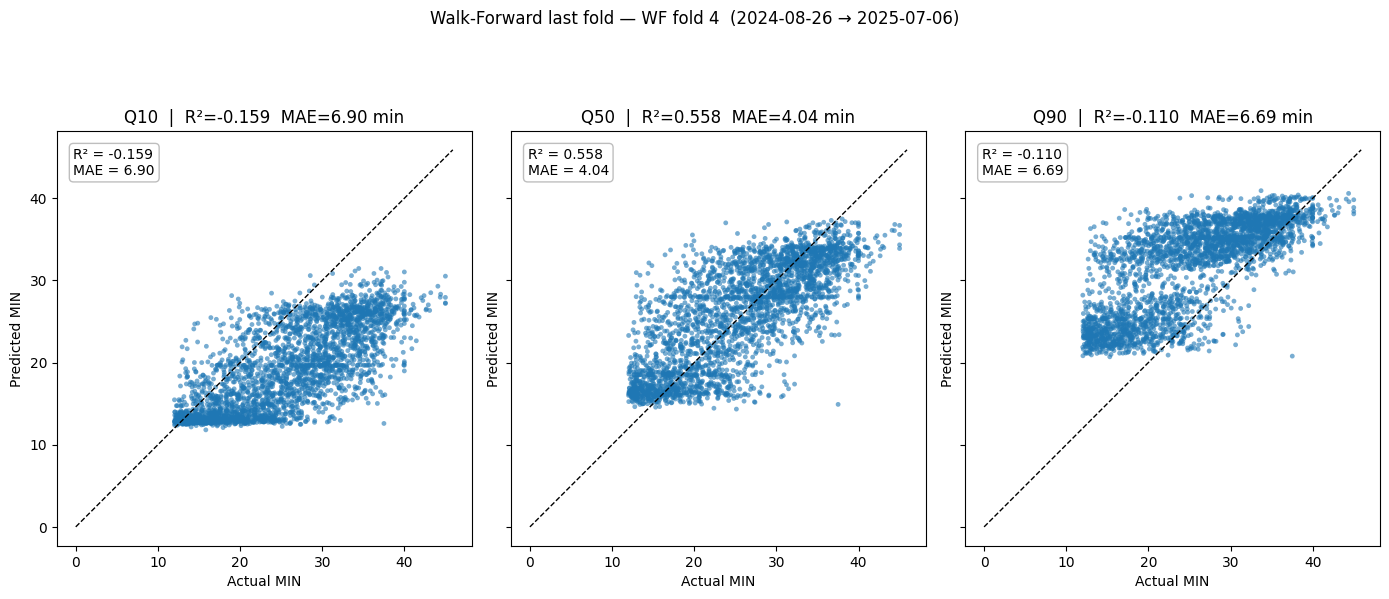

Per-quantile fit on last validation fold:
  Q10: R²=-0.159  MAE=6.897 min
  Q50: R²=+0.558  MAE=4.039 min
  Q90: R²=-0.110  MAE=6.691 min

Coverage per quantile (should match quantile value):
  Q10: 11.7%  (target 10%, delta +1.7%)  ✓
  Q50: 49.7%  (target 50%, delta -0.3%)  ✓
  Q90: 88.9%  (target 90%, delta -1.1%)  ✓

80% interval width (Q10→Q90):
  mean   : 12.64 min
  median : 12.31 min
  std    : 2.08 min


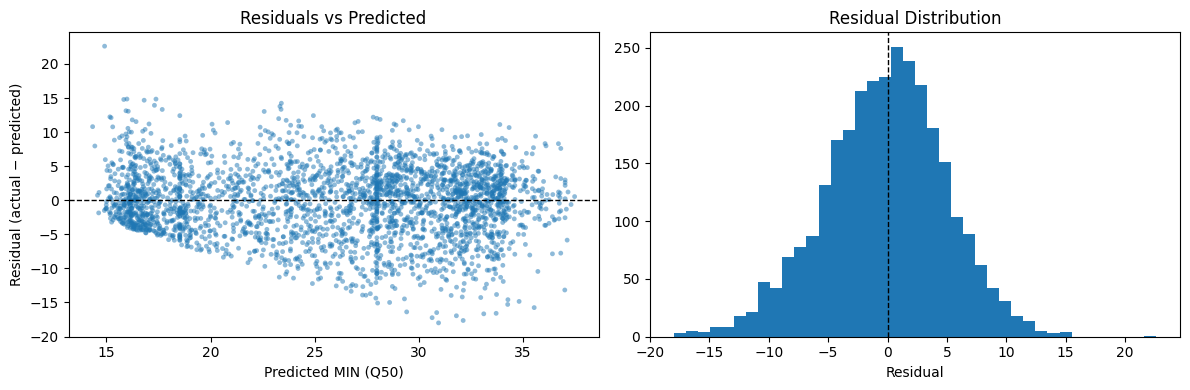


Residual summary:
  mean bias : -0.225 min  (close to 0 = unbiased)
  std       : 5.115 min

Residuals by role:
  Starters   | n= 1990 | bias=-0.512 | std=5.394
  Bench      | n=  952 | bias=+0.375 | std=4.417

Residuals by minutes tier:
  <12.8 min  | n=   73 | bias=-5.126 | std=2.060
  12.8-21.8 min | n=  945 | bias=-3.394 | std=4.526
  21.8-30 min | n= 1118 | bias=-0.102 | std=4.627
  30+ min    | n=  806 | bias=+3.763 | std=3.394


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

y_true = y_val_last.values
pred_low = preds_last["q_0.10"]
pred_mid = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]
preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}
    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.2f} min")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.3f} min")

print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta = coverage - q_target
    flag = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.2f} min")
print(f"  median : {np.median(interval_width):.2f} min")
print(f"  std    : {interval_width.std():.2f} min")

residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")
axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

starting_last = ppm_df.loc[X_val_last.index, "starting"].values
print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")

print("\nResiduals by minutes tier:")
for tier, fn in MIN_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")



── q_0.10 ──


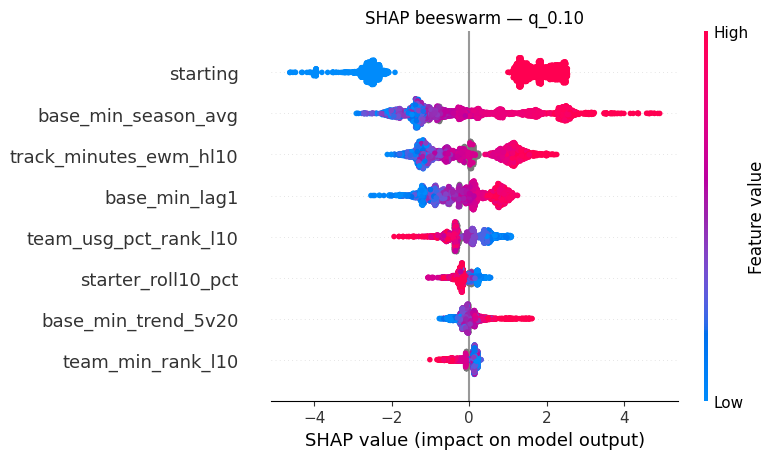


── q_0.50 ──


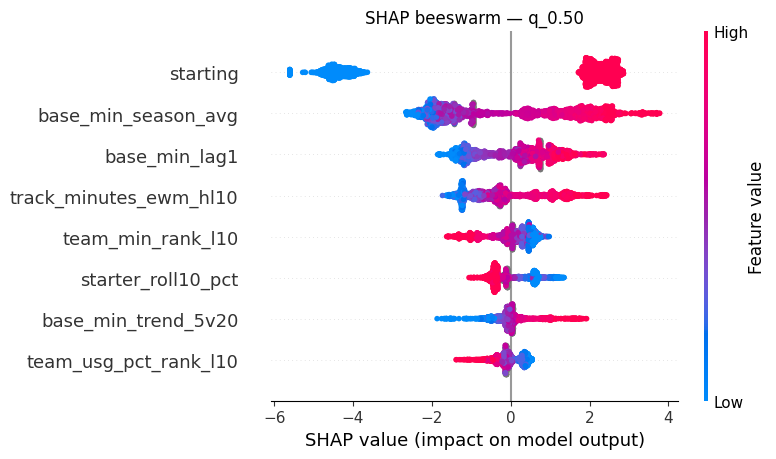


── q_0.90 ──


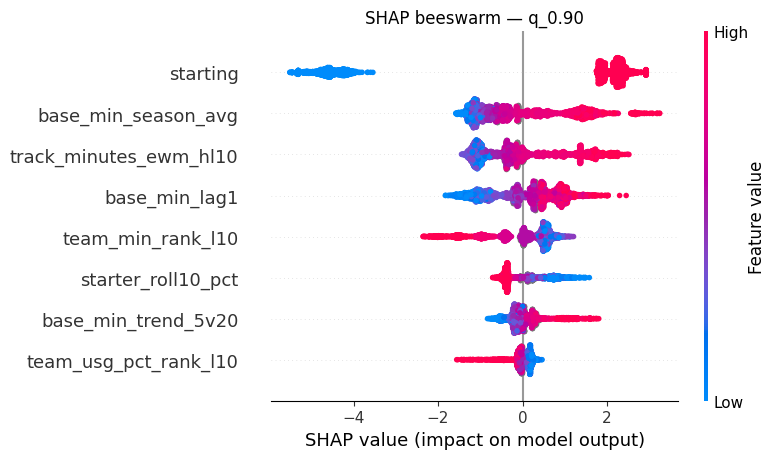

In [28]:
import shap

for q_key, model in models_last.items():
    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()


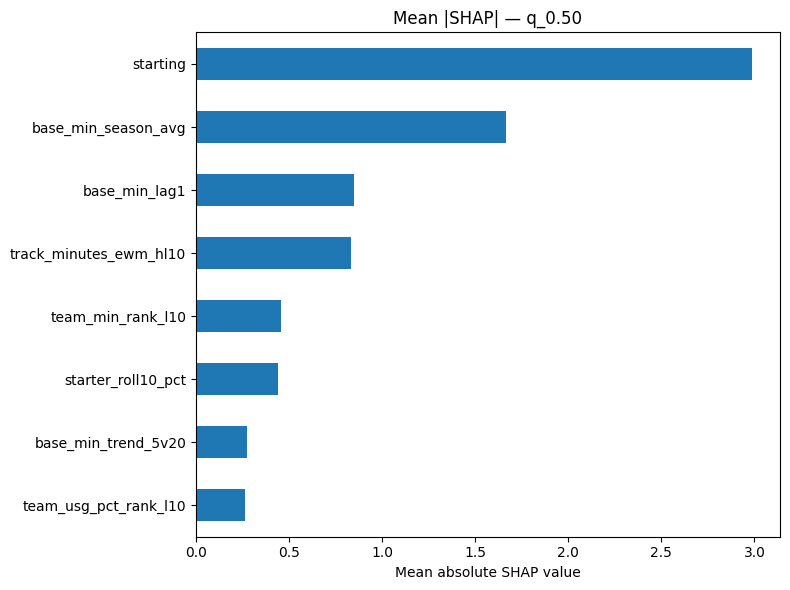

In [29]:
model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [30]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())


Permutation importance (val set) — higher = more important, significant = p<0.05
                  feature  importance      std  p_value  significant
1                starting     0.66984  0.02437      0.0         True
2     base_min_season_avg     0.23339  0.01327      0.0         True
3           base_min_lag1     0.11345  0.01039      0.0         True
4  track_minutes_ewm_hl10     0.10652  0.00934      0.0         True
5       team_min_rank_l10     0.05871  0.00614      0.0         True
6      starter_roll10_pct     0.03603  0.00706      0.0         True
7     base_min_trend_5v20     0.02290  0.00448      0.0         True
8   team_usg_pct_rank_l10     0.01277  0.00324      0.0         True


In [31]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]

ablation_df = run_feature_ablation(
    MIN_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)


Baseline RMSE (all features): 5.1199
                  feature  ablated_rmse  delta_rmse
1                starting        5.4487      0.3288
2      starter_roll10_pct        5.1540      0.0341
3     base_min_trend_5v20        5.1428      0.0229
4       team_min_rank_l10        5.1357      0.0158
5     base_min_season_avg        5.1347      0.0148
6   team_usg_pct_rank_l10        5.1341      0.0143
7  track_minutes_ewm_hl10        5.1294      0.0095
8           base_min_lag1        5.1239      0.0040


In [32]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())


                  feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus  keep
1                starting       2.987823          1          1          0.66984              0.02437  2.666161e-43          0.3288   1.000000   1.000000   1.000000  True
2     base_min_season_avg       1.667936          2          2          0.23339              0.01327  1.091256e-37          0.0148   0.558245   0.348426   0.453336  True
3           base_min_lag1       0.847117          3          3          0.11345              0.01039  1.031263e-31          0.0040   0.283523   0.169369   0.226446  True
4  track_minutes_ewm_hl10       0.834793          4          4          0.10652              0.00934  2.931139e-32          0.0095   0.279398   0.159023   0.219211  True
5       team_min_rank_l10       0.454066          5          5          0.05871              0.00614  4.535379e-30          0.0158   0.151972   0.0876

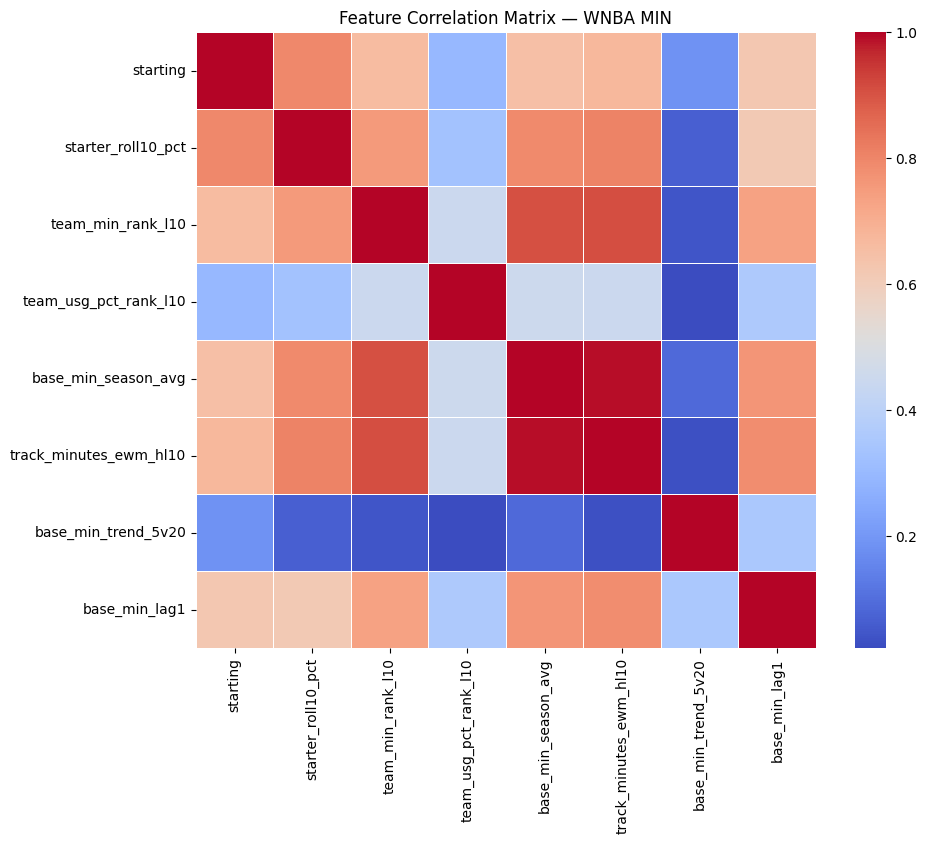

--- High Correlation Report (Threshold > 0.95) ---
track_minutes_ewm_hl10 <-> base_min_season_avg: 0.9919


['track_minutes_ewm_hl10']

In [33]:
correlated_features = analyze_correlations(
    df, MIN_FEATURES, title="Feature Correlation Matrix — WNBA MIN"
)
correlated_features


In [34]:
holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]


── 2026 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).

2026 Blind Holdout
  Overall  | n= 3052 | MAE: 3.569 | R²: 0.585 | 80% Coverage: 84.9%
  Starters   | n= 1985 | MAE: 3.754 | Coverage: 86.2%
  Bench      | n= 1067 | MAE: 3.225 | Coverage: 82.6%
  <12.8 min  | n=   83 | MAE: 5.085 | Coverage: 1.2%
  12.8-21.8 min | n= 1068 | MAE: 3.740 | Coverage: 85.0%
  21.8-30 min | n= 1295 | MAE: 3.224 | Coverage: 92.3%
  30+ min    | n=  606 | MAE: 3.796 | Coverage: 80.5%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean)  : 3.890
  Holdout MAE              : 3.569
  Gap                      : -0.321  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 8.9%  target: 10%  delta: -1.1%  ✓
  q_0.50 | actual coverage: 54.6%  target: 50%  delta: +4.6%  ✓
  q_0.90 | actual coverage: 93.9%  target: 90%  delt

In [35]:
naive_holdout_results = evaluate_holdout_vs_naive(
    ppm_holdout,
    preds_ho,
    target_col=TARGET_COL,
    naive_primary=NAIVE_PRIMARY,
    naive_secondary=NAIVE_SECONDARY,
    naive_wf_primary=naive["naive_wf_primary"],
    wf_test_primary=naive["wf_test_primary"],
    alpha=ALPHA,
    holdout_label=f"{HOLDOUT_SEASON} holdout",
)


───────────────────────────────────────────────────────
2026 holdout — model vs frozen naive baselines
  H0: model does not beat naive | H1: model beats naive (α=0.05)

  PRIMARY (base_min_season_avg)
    n paired   : 2,899
    MAE model  : 3.556
    MAE naive  : 4.353
    ΔMAE (m−n) : -0.797
    Wilcoxon p : 1.789e-33
    Decision   : REJECT H0 — model significantly better

  secondary (base_min_lag1)
    n paired   : 2,899
    MAE model  : 3.556
    MAE naive  : 5.086
    ΔMAE (m−n) : -1.529
    Wilcoxon p : 2.43e-83
    Decision   : REJECT H0 — model significantly better


### Complexity ladder — naive → linear quantile → XGB

Report-only baseline (not shipped). Same `MIN_FEATURES` and walk-forward / holdout masks as XGB.

- **Linear:** `SimpleImputer(median)` → `StandardScaler` → `QuantileRegressor` (Q10/Q50/Q90)
- Pairwise Wilcoxon on |error|: linear vs naive, XGB vs linear (α = 0.05)
- Authoritative decision remains XGB vs frozen naive on holdout; this ladder answers “does nonlinearity buy anything?”


In [36]:
linear = run_quantile_linear_baseline(
    X, y, ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    naive_primary=NAIVE_PRIMARY,
    xgb_preds_last=preds_last,
    xgb_preds_ho=preds_ho,
    last_fold=last_fold,
    role_col=ROLE_COL,
    quantiles=QUANTILES,
    alpha=ALPHA,
    holdout_label=f"{HOLDOUT_SEASON} holdout",
)


── Quantile linear baseline (report-only) ───────────────────────────
  Features : 8
  Quantiles: [0.1, 0.5, 0.9]
  L1 alpha : 0.0

Three-way MAE by walk-forward fold:
  Fold                                             Naive   Linear      XGB     ΔL−N     ΔX−L    Cov80
  WF fold 1  (2022-06-30 → 2023-06-17)             4.850    3.898    3.830   -0.952   -0.068   82.1%
  WF fold 2  (2023-06-17 → 2023-10-01)             4.940    3.967    3.924   -0.973   -0.044   79.7%
  WF fold 3  (2023-10-01 → 2024-08-26)             4.803    3.904    3.767   -0.899   -0.137   81.0%
  WF fold 4  (2024-08-26 → 2025-07-06)             5.116    4.142    4.039   -0.975   -0.102   78.0%

────────────────────────────────────────────────────────────
Walk-forward last-fold pairwise tests:
  WF last fold: linear vs naive
    MAE challenger=4.132  baseline=5.116  Δ=-0.985  p=9.05e-35  REJECT
  WF last fold: XGB vs linear
    MAE challenger=4.039  baseline=4.142  Δ=-0.102  p=3.755e-07  REJECT

Linear | 2026 holdo

In [37]:
from sklearn.metrics import mean_absolute_error

save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=MIN_FEATURES,
    artifact_stem=ARTIFACT_STEM,
    naive_holdout_results=naive_holdout_results,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (holdout): {mean_absolute_error(y_ho, test_preds):.3f}")
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

predict_quantiles(models_loaded, feature_names, X_ho.head(3))


Saved to /Users/alexgonzalez/Documents/NBA-Prop-Predictor/models/saved_models/min_wnba_model_2026-07-22.joblib
Loaded /Users/alexgonzalez/Documents/NBA-Prop-Predictor/models/saved_models/min_wnba_model_2026-07-22.joblib
Loaded model MAE (holdout): 3.569
Trained on data up to      : 2025-10-10
Holdout through            : 2026-07-22


,q10,q50,q90
0,13.161235,18.279322,26.113043
1,18.729353,27.521181,34.685413
2,13.161235,18.279322,26.113043
